## Docking environment

In [1]:
import pandas as pd

# Read docking results
docking_results = pd.read_csv('PptT/score0/pptt_score0_results_top1.csv')

In [2]:
docking_results

,compound_id,smiles,free_energy,intermolecular_energy,internal_energy,cluster_id,cluster_size,pose_index,file_path
0,589434_0,O=C([O-])c1cc2c(cc1C(=O)[O-])C(NS(=O)(=O)c1ccc...,-15.14,-16.93,-0.42,1,6,7,score0_03/589434_0.dlg.gz
1,670658_0,Cc1ccc(-n2cc(C(=O)N[C@H]3C[C@@H](Cc4nn[n-]n4)C...,-14.44,-16.23,-1.17,1,11,10,score0_03/670658_0.dlg.gz
2,343591_0,O=C([O-])c1cc(C(=O)[O-])cc(C(=O)N2Cc3ccccc3-c3...,-14.02,-15.21,-0.57,1,20,1,score0_02/343591_0.dlg.gz
3,941313_0,Cc1ccc(-c2ccc(C(C)(C)C)cc2)cc1C(=O)N1CC(c2nnn[...,-13.96,-15.15,-1.03,1,17,7,score0_04/941313_0.dlg.gz
4,147839_0,CC(C)(CCC(=O)N1C2CCCC1C(C(=O)[O-])C2C(=O)[O-])...,-13.93,-15.72,-0.05,1,20,4,score0_02/147839_0.dlg.gz
...,...,...,...,...,...,...,...,...,...
14172,729064_0,CC1(C)Cc2ccccc2N(Cc2nnc(-c3cccc(C#N)c3)o2)C1,-11.37,-12.57,-0.84,1,14,9,score0_04/729064_0.dlg.gz
14173,109856_0,COC(=O)c1ccc2oc(C=Cc3ncc(C(=O)[O-])cc3C#N)cc2c1,-11.37,-13.45,-0.50,1,8,13,score0_01/109856_0.dlg.gz
14174,1288336_0,CN(CC(=O)N1CCN2C(=O)NCCC2C1)S(=O)(=O)c1ccc2ccc...,-11.37,-12.86,-0.63,1,5,7,score0_01/1288336_0.dlg.gz
14175,185828_0,O=C([O-])C1CCC(S(=O)(=O)N2CCC(CC3CC3)CC2)CC1,-11.37,-12.86,-0.91,1,17,14,score0_02/185828_0.dlg.gz


In [3]:
#from docking.docking_utils import get_poses_from_dlg

In [4]:
'''
root_data_dir = '/work/users/s/h/shuhang/argo_docking/PptT'
import os

mol_poses = []
for i, row in docking_results.head(100).iterrows():
    mol_poses.append(get_poses_from_dlg(os.path.join(root_data_dir, row['file_path']), row['pose_index']))

print(mol_poses)
'''

"\nroot_data_dir = '/work/users/s/h/shuhang/argo_docking/PptT'\nimport os\n\nmol_poses = []\nfor i, row in docking_results.head(100).iterrows():\n    mol_poses.append(get_poses_from_dlg(os.path.join(root_data_dir, row['file_path']), row['pose_index']))\n\nprint(mol_poses)\n"

In [5]:
'''
from rdkit import Chem
writer = Chem.SDWriter('rotbonds_sample.sdf')
for mol in mol_poses:
    writer.write(mol)
writer.close()
'''

"\nfrom rdkit import Chem\nwriter = Chem.SDWriter('rotbonds_sample.sdf')\nfor mol in mol_poses:\n    writer.write(mol)\nwriter.close()\n"

## Argo Environment

In [37]:
# Now using environment: argo
from rdkit import Chem

suppl = Chem.SDMolSupplier('rotbonds_sample.sdf')
mols = [mol for mol in suppl if mol is not None]
print(f"Read {len(mols)} molecules from SDF file")

mols = mols[0:20]

Read 100 molecules from SDF file


In [38]:
scores = docking_results['free_energy'].head(20).values

In [39]:
from argo.frag_utils import SAFECodec, find_connected_rotatable_bond_ends

'''
safecodec = SAFECodec(slicer=find_connected_rotatable_bond_ends)

safecodec.encode(mols[1])
'''

'\nsafecodec = SAFECodec(slicer=find_connected_rotatable_bond_ends)\n\nsafecodec.encode(mols[1])\n'

In [40]:
find_connected_rotatable_bond_ends(mols[0])

[(1, 3), (8, 9), (12, 13), (14, 17), (20, 21)]

In [41]:
import numpy as np
from rdkit import Chem

def compute_fragment_centroids(mol, bonds, conf_id=-1, mass_weighted=False):
    # bonds: list of (atom_i, atom_j) you got from find_connected_rotatable_bond_ends
    num_atoms = mol.GetNumAtoms()

    # Build a temporary molecule with cut bonds and attach dummy atoms (*) at the cut ends
    rw = Chem.RWMol(Chem.Mol(mol))
    # Remove the bonds to split fragments
    for i, j in bonds:
        if rw.GetBondBetweenAtoms(i, j) is not None:
            rw.RemoveBond(i, j)
    # Add exit-vector dummies bound to each cut endpoint
    for i, j in bonds:
        a1 = Chem.Atom(0)
        a2 = Chem.Atom(0)
        idx1 = rw.AddAtom(a1)
        idx2 = rw.AddAtom(a2)
        rw.AddBond(i, idx1, Chem.BondType.SINGLE)
        rw.AddBond(j, idx2, Chem.BondType.SINGLE)
    fragged = rw.GetMol()

    # Get fragment membership and fragment molecules (with dummies)
    frags_idx_all = Chem.GetMolFrags(fragged, asMols=False)
    frags_mols = Chem.GetMolFrags(fragged, asMols=True, sanitizeFrags=True)

    # Map original atoms to fragments (ignore dummy atoms)
    atom_to_frag = [-1] * num_atoms
    for frag_idx, frag in enumerate(frags_idx_all):
        for a in frag:
            if a < num_atoms:
                atom_to_frag[a] = frag_idx

    # Count exit vectors per fragment (each cut contributes one to each side)
    exit_counts = [0] * len(frags_idx_all)
    for i, j in bonds:
        fi = atom_to_frag[i]
        fj = atom_to_frag[j]
        if fi != -1:
            exit_counts[fi] += 1
        if fj != -1:
            exit_counts[fj] += 1

    # Coordinates from the original conformer
    conf = mol.GetConformer(conf_id)
    positions = np.array([list(conf.GetAtomPosition(i)) for i in range(num_atoms)])

    masses = None
    if mass_weighted:
        masses = np.array([mol.GetAtomWithIdx(i).GetMass() for i in range(num_atoms)])

    results = []
    for frag_idx, frag in enumerate(frags_idx_all):
        # Use only original atoms (exclude dummy atoms appended to fragged)
        idxs_list = [a for a in frag if a < num_atoms]
        idxs = np.array(idxs_list, dtype=int)
        if mass_weighted:
            w = masses[idxs][:, None]
            centroid = (positions[idxs] * w).sum(axis=0) / w.sum()
        else:
            centroid = positions[idxs].mean(axis=0)
        # SMILES with exit vectors ([*]) preserved
        frag_smiles = Chem.MolToSmiles(frags_mols[frag_idx], isomericSmiles=True, canonical=True)
        results.append((tuple(idxs_list), centroid, exit_counts[frag_idx], frag_smiles))
    return results

# Usage
# ends = find_connected_rotatable_bond_ends(mol)
# centroids = compute_fragment_centroids(mol, ends)

In [42]:
# Create dictionary to store fragments by number of exit vectors
fragments_by_exits = {}

# Iterate through all molecules
for i, mol in enumerate(mols):
    score = scores[i]
    # Get rotatable bond ends
    ends = find_connected_rotatable_bond_ends(mol)
    
    # Get centroids for each fragment
    centroids = compute_fragment_centroids(mol, ends)
    
    # Store each fragment
    for frag_atoms, centroid, n_exits, smiles in centroids:
        if n_exits not in fragments_by_exits:
            fragments_by_exits[n_exits] = []
        
        fragments_by_exits[n_exits].append({
            'smiles': smiles,
            'centroid': centroid,
            'score': score
        })

# Print summary
for n_exits in sorted(fragments_by_exits.keys()):
    print(f"Fragments with {n_exits} exit vectors: {len(fragments_by_exits[n_exits])}")

Fragments with 1 exit vectors: 48
Fragments with 2 exit vectors: 51
Fragments with 3 exit vectors: 8


In [43]:
fragments_by_exits[1]

[{'smiles': '*C(=O)[O-]',
  'centroid': array([ 3.009     , 11.688     ,  8.33433333]),
  'score': np.float64(-15.14)},
 {'smiles': '*C(=O)[O-]',
  'centroid': array([5.08066667, 9.409     , 6.451     ]),
  'score': np.float64(-15.14)},
 {'smiles': '*C1CCCCC1',
  'centroid': array([4.41683333, 0.04883333, 4.17616667]),
  'score': np.float64(-15.14)},
 {'smiles': '*c1ccc(C)cc1',
  'centroid': array([ 5.37557143, -0.51242857,  4.92557143]),
  'score': np.float64(-14.44)},
 {'smiles': '*c1nn[n-]n1',
  'centroid': array([3.7062, 9.9956, 6.7138]),
  'score': np.float64(-14.44)},
 {'smiles': '*C(C)(C)C',
  'centroid': array([ 8.9825 ,  2.474  , 10.06175]),
  'score': np.float64(-14.44)},
 {'smiles': '*C(=O)[O-]',
  'centroid': array([ 1.27166667,  7.92833333, 10.75833333]),
  'score': np.float64(-14.02)},
 {'smiles': '*C(=O)[O-]',
  'centroid': array([5.011     , 9.23533333, 6.492     ]),
  'score': np.float64(-14.02)},
 {'smiles': '*N1Cc2ccccc2-c2ccccc21',
  'centroid': array([5.79307143, 2

In [44]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np

def cluster_fragments(fragments, threshold=1.0):
    # Extract centroids into array
    centroids = np.array([f['centroid'] for f in fragments])
    
    # Perform clustering
    clustering = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=threshold,
        metric='euclidean',
        linkage='single'
    )
    
    # Get cluster labels
    labels = clustering.fit_predict(centroids)
    
    # Group fragments by cluster
    clusters = {}
    for i, label in enumerate(labels):
        if label not in clusters:
            clusters[label] = []
        clusters[label].append(fragments[i])
        
    return clusters

# Cluster fragments for each exit vector category
clustered_fragments = {}
for n_exits, frags in fragments_by_exits.items():
    print(f"\nClustering fragments with {n_exits} exit vectors:")
    clusters = cluster_fragments(frags, threshold=1.0)
    clustered_fragments[n_exits] = clusters
    print(f"Found {len(clusters)} clusters")
    
    # Print size of each cluster
    for cluster_id, cluster in clusters.items():
        print(f"Cluster {cluster_id}: {len(cluster)} fragments")


Clustering fragments with 1 exit vectors:
Found 14 clusters
Cluster 10: 2 fragments
Cluster 1: 20 fragments
Cluster 13: 1 fragments
Cluster 0: 4 fragments
Cluster 5: 3 fragments
Cluster 7: 1 fragments
Cluster 4: 8 fragments
Cluster 6: 1 fragments
Cluster 11: 1 fragments
Cluster 2: 3 fragments
Cluster 8: 1 fragments
Cluster 3: 1 fragments
Cluster 12: 1 fragments
Cluster 9: 1 fragments

Clustering fragments with 3 exit vectors:
Found 6 clusters
Cluster 2: 2 fragments
Cluster 4: 1 fragments
Cluster 0: 2 fragments
Cluster 3: 1 fragments
Cluster 1: 1 fragments
Cluster 5: 1 fragments

Clustering fragments with 2 exit vectors:
Found 14 clusters
Cluster 5: 14 fragments
Cluster 7: 2 fragments
Cluster 2: 14 fragments
Cluster 8: 1 fragments
Cluster 1: 6 fragments
Cluster 11: 2 fragments
Cluster 10: 1 fragments
Cluster 3: 3 fragments
Cluster 0: 3 fragments
Cluster 9: 1 fragments
Cluster 13: 1 fragments
Cluster 12: 1 fragments
Cluster 6: 1 fragments
Cluster 4: 1 fragments


In [45]:
clustered_fragments

{1: {np.int64(10): [{'smiles': '*C(=O)[O-]',
    'centroid': array([ 3.009     , 11.688     ,  8.33433333]),
    'score': np.float64(-15.14)},
   {'smiles': '*C(=O)[O-]',
    'centroid': array([ 3.22266667, 11.41233333,  7.67533333]),
    'score': np.float64(-13.65)}],
  np.int64(1): [{'smiles': '*C(=O)[O-]',
    'centroid': array([5.08066667, 9.409     , 6.451     ]),
    'score': np.float64(-15.14)},
   {'smiles': '*c1nn[n-]n1',
    'centroid': array([3.7062, 9.9956, 6.7138]),
    'score': np.float64(-14.44)},
   {'smiles': '*C(=O)[O-]',
    'centroid': array([5.011     , 9.23533333, 6.492     ]),
    'score': np.float64(-14.02)},
   {'smiles': '*c1nnn[n-]1',
    'centroid': array([4.8682, 8.9898, 6.3742]),
    'score': np.float64(-13.96)},
   {'smiles': '*C(=O)[O-]',
    'centroid': array([5.37766667, 9.342     , 6.36233333]),
    'score': np.float64(-13.93)},
   {'smiles': '*C(=O)[O-]',
    'centroid': array([4.86233333, 9.31733333, 6.53033333]),
    'score': np.float64(-13.9)},
  

In [46]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

# Function to visualize clusters
def visualize_cluster(fragments, title=""):
    # Create a figure with subplots for each fragment
    n_frags = len(fragments)
    n_cols = min(5, n_frags)  # Max 5 molecules per row
    n_rows = (n_frags + n_cols - 1) // n_cols
    
    fig = plt.figure(figsize=(4*n_cols, 4*n_rows))
    plt.suptitle(title, fontsize=16)
    
    for i, frag in enumerate(fragments):
        mol = Chem.MolFromSmiles(frag['smiles'])
        ax = fig.add_subplot(n_rows, n_cols, i+1)
        img = Draw.MolToImage(mol)
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

'''
# Visualize largest clusters for each exit vector category
for n_exits, clusters in clustered_fragments.items():
    # Sort clusters by size
    sorted_clusters = sorted(clusters.items(), key=lambda x: len(x[1]), reverse=True)
    
    # Show top 3 largest clusters
    for cluster_id, cluster in sorted_clusters[:3]:
        title = f"{n_exits} exit vectors - Cluster {cluster_id} ({len(cluster)} fragments)"
        visualize_cluster(cluster, title)
'''

'\n# Visualize largest clusters for each exit vector category\nfor n_exits, clusters in clustered_fragments.items():\n    # Sort clusters by size\n    sorted_clusters = sorted(clusters.items(), key=lambda x: len(x[1]), reverse=True)\n\n    # Show top 3 largest clusters\n    for cluster_id, cluster in sorted_clusters[:3]:\n        title = f"{n_exits} exit vectors - Cluster {cluster_id} ({len(cluster)} fragments)"\n        visualize_cluster(cluster, title)\n'

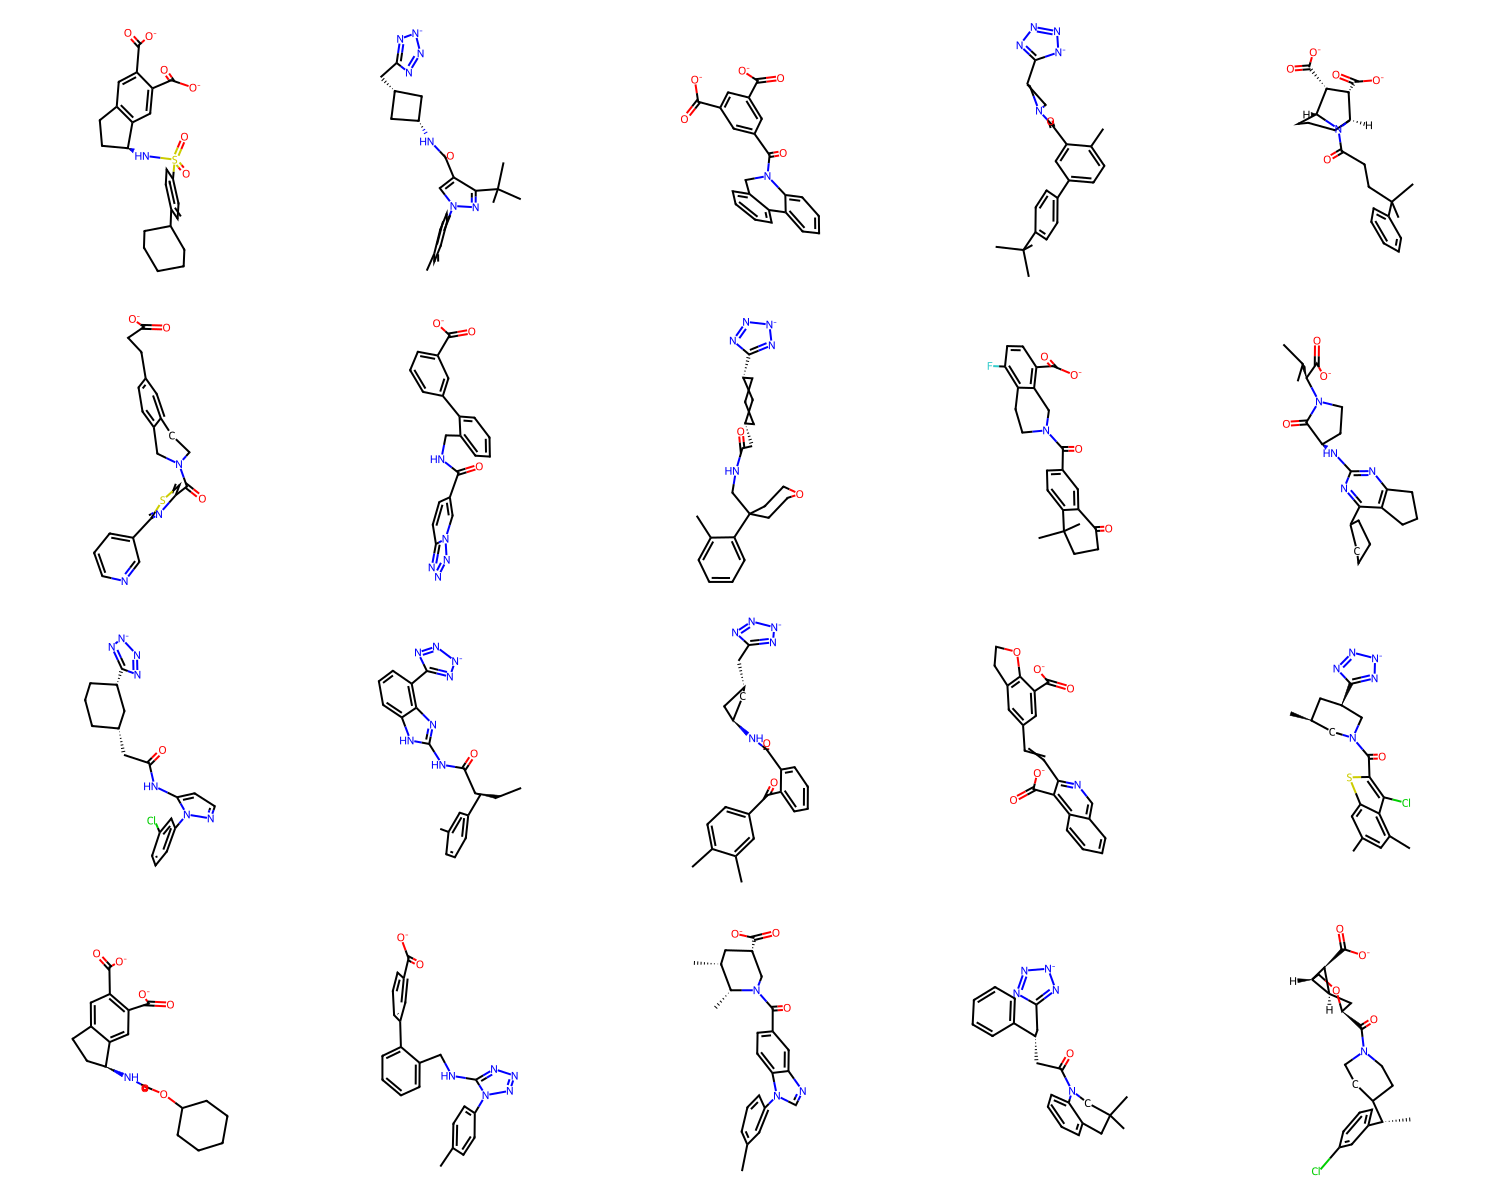

In [47]:
# Draw all molecules in a single grid
img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(300,300))
display(img)

In [48]:
# Import required packages for 3D plotting
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# Extract centroids and create a DataFrame
centroids_data = []
for n_exits, clusters in clustered_fragments.items():
    for cluster_id, cluster in clusters.items():
        # Get centroid and average score for this cluster
        centroid = np.mean([frag['centroid'] for frag in cluster], axis=0)
        avg_score = np.mean([frag['score'] for frag in cluster])
        centroids_data.append({
            'x': centroid[0],
            'y': centroid[1], 
            'z': centroid[2],
            'n_exits': n_exits,
            'cluster_size': len(cluster),
            'cluster_id': cluster_id,
            'avg_score': avg_score
        })

df = pd.DataFrame(centroids_data)

# Create 3D scatter plot using plotly
fig = px.scatter_3d(df, 
                    x='x', y='y', z='z',
                    color='n_exits',
                    size='cluster_size', 
                    hover_data=['cluster_id', 'cluster_size'],
                    title='Fragment Cluster Centers in 3D Space',
                    labels={
                        'avg_score': 'Average Score',
                        'cluster_size': 'Cluster Size',
                        'n_exits': 'Number of Exit Vectors'
                    })

# Update layout for better visualization
fig.update_layout(
    scene = dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    )
)

# Show interactive plot
fig.show()